In [1]:
import pandas as pd 
import numpy as np 
import sys
sys.path.append('/volume_4/research/seongbong/flywire/geosmin_project_version_update/code')
import connectivity_based_clustering
import matplotlib.pyplot as plt
import pickle
from fafbseg import flywire
class_df = pd.read_csv('/volume_3/research/seongbong/flywire/data/neuronlist/classification_v783.csv')

def determine_num_LR(fids):
    side,counts = np.unique(class_df[np.isin(class_df.root_id,fids)].side.values,return_counts=True)
    return dict(zip(side,counts))

path_comp = '/volume_4/research/seongbong/flywire/GRN_project_new/data/Completeness_783.csv'
comp_df = pd.read_csv(path_comp)


tastekin = pd.read_excel('/volume_4/research/seongbong/flywire/GRN_project_new/figure2/Tastekin et al._bioRxiv(preprint)_2025_cell ID.xlsx',sheet_name='GRNs')
tastekin =tastekin[(tastekin.Connectome=='FAFB – Flywire')&(tastekin.Subclass=='Labellar Bristle')]
tastekin_fid2type = dict(zip(tastekin.Body_ID,tastekin.Subtype))

In [2]:
labial_GRNs_candi = labial_sensory = pickle.load(open('/volume_4/research/seongbong/flywire/GRN_project_new/data/All_mxlbn_GRNs_v783.pkl','rb')) + [720575940606254002,720575940622358057,720575940622236671,720575940627397263,720575940625752778,720575940625615705,720575940630229007,720575940611018714,720575940616971035,720575940631106664,720575940632341452]

mat_g_old = pd.read_csv('/volume_4/research/seongbong/flywire/GRN_project_new/figure1/mat_g_all_GRNs.csv',index_col='Unnamed: 0')
len(labial_GRNs_candi)

224

In [3]:
mat_g = connectivity_based_clustering.make_adjacency_matrix_GRN_to_2ndtype(labial_GRNs_candi)
# mat_g = mat_g[np.intersect1d(mat_g.columns,mat_g_old.columns.astype(float))]

# mat_g.drop([ 2420,  6028,  7068,  7459,  9064, 11476],axis=1)
Z = connectivity_based_clustering.cluster_GRNs(mat_g)
colors = []

Calc. similarity:   0%|          | 0/50176 [00:00<?, ?it/s]

In [4]:

import distinctipy
from color_utils import *
# colors_wanted = distinctipy.get_colors(20)
# colors_wanted = [rgb_to_hex(x) for x in colors_wanted][::-1]
colors_wanted = ['#0a7f25', '#00ff00','#ff00ff', '#7fbf7f', '#007fff', '#B2C6D5','#364E68','#b3ff47','#ac0902', '#ff7f00', '#610c9f'][::-1]

Calc. similarity:   0%|          | 0/50176 [00:00<?, ?it/s]

/volume_4/research/seongbong/flywire/geosmin_project_version_update/code/connectivity_based_clustering.py:120: RuntimeWarning: divide by zero encountered in log10
  mat_data = np.log10(mat_g_sorted[:, np.argsort(np.sum(mat_g_arr,axis=0))[::-1][:50]])


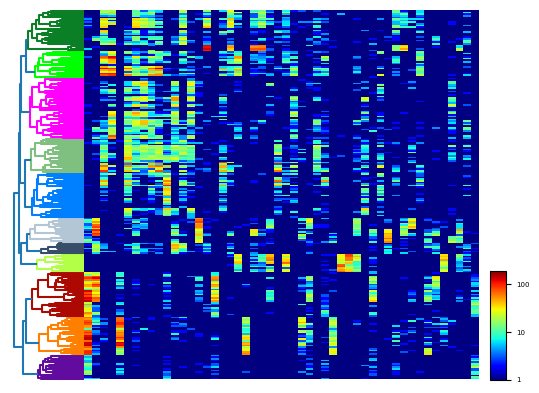

In [5]:
fig,ax = plt.subplots(1,1)
dn = connectivity_based_clustering.draw_dendrogram_with_adjmat(fig,mat_g,labial_GRNs_candi,colors=colors_wanted,threshold=1.86)
ax.set_xticks([])
ax.set_yticks([])
ax.axis('off')

cells = np.array(dn['ivl'])
colors = np.array(dn['leaves_color_list'])
type_name = [f"L{list(dict.fromkeys(colors)).index(c)+1}" for c in colors]
cluster_info = pd.DataFrame(columns=['flyid','type'])
cluster_info['flyid'] = cells
cluster_info['type'] = type_name
cluster_info['colors'] = colors


# cluster_info['tastekin'] = [tastekin_fid2type[x] for x in cells]
# cluster_info.to_parquet('/volume_4/research/seongbong/flywire/GRN_project_new/data/labial_cluster_info_v783.parquet')
# cluster_info.to_csv('/volume_4/research/seongbong/flywire/GRN_project_new/data/labial_cluster_info_v783.csv')

In [6]:
for t,tdf in cluster_info.groupby(by='type'):
    print(t,len(tdf))

L1 15
L10 16
L11 25
L2 23
L3 27
L4 11
L5 7
L6 15
L7 27
L8 21
L9 37


In [7]:
for t,tdf in cluster_info.groupby(by='type'):
    print(t,len(tdf))

L1 15
L10 16
L11 25
L2 23
L3 27
L4 11
L5 7
L6 15
L7 27
L8 21
L9 37


In [8]:
# for t,tdf in cluster_info.groupby(by='type'):
#     print(t,tdf.flyid.values)

df = pd.read_parquet('/volume_4/research/seongbong/flywire/GRN_project_new/data/labial_cluster_info_v783.parquet')

print(df[df['type']=='high_salt'].flyid.values)
len(df[df['type']=='high_salt'].flyid.values)

[720575940615516319 720575940634023961 720575940614302370
 720575940631393484 720575940607347634 720575940632510479
 720575940616851286 720575940631656504 720575940621508479
 720575940622200233 720575940629884119 720575940629025324
 720575940618709371 720575940627490663 720575940641339611
 720575940609919897 720575940607737099 720575940622413508
 720575940617801499 720575940639043280 720575940622825736
 720575940617181725 720575940617937543 720575940610296622
 720575940629510338 720575940632880173 720575940629176663]


27

Calc. similarity:   0%|          | 0/50176 [00:00<?, ?it/s]

/volume_4/research/seongbong/flywire/geosmin_project_version_update/code/connectivity_based_clustering.py:204: RuntimeWarning: divide by zero encountered in log10
  mat_data = np.log10(mat_g_arr[idx, :][:, top_cols].T)


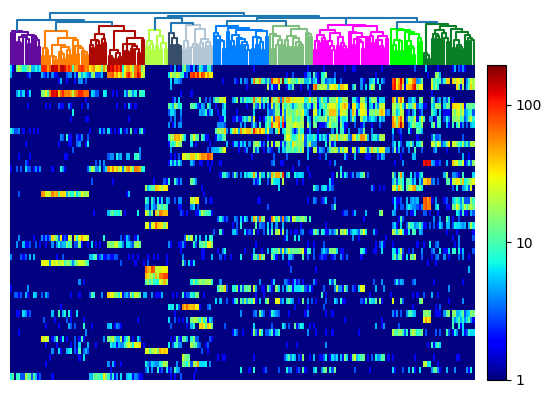

In [9]:
fig,ax = plt.subplots(1,1)
dn = connectivity_based_clustering.draw_dendrogram_with_adjmat_vertical(fig,mat_g,labial_GRNs_candi,colors=colors_wanted,threshold=1.86)
ax.set_xticks([])
ax.set_yticks([])
ax.axis('off')

cells = np.array(dn['ivl'])
colors = np.array(dn['leaves_color_list'])
type_name = [f"L{list(dict.fromkeys(colors)).index(c)+1}" for c in colors]
cluster_info = pd.DataFrame(columns=['flyid','type'])
cluster_info['flyid'] = cells
cluster_info['type'] = type_name
cluster_info['colors'] = colors

plt.savefig('labial_clustering_result.svg',bbox_inches='tight')
# cluster_info['tastekin'] = [tastekin_fid2type[x] for x in cells]
# cluster_info.to_parquet('/volume_4/research/seongbong/flywire/GRN_project_new/data/labial_cluster_info_v783.parquet')
# cluster_info.to_csv('/volume_4/research/seongbong/flywire/GRN_project_new/data/labial_cluster_info_v783.csv')

In [13]:
pwd

'/volume_4/research/seongbong/flywire/geosmin_project_version_update/figure_supplementary/figure4/Labellar_connectivity_clustering'

In [11]:
cluster_info.to_parquet('cluster_info.parquet')